In [1]:
from polypart.algorithms import build_partition_tree
from polypart.generators import (
    get_random_arrangement,
    sample_poisson_zero_cell_polytope,
)

In [2]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from polypart.experiments.stats import get_ppart_stats

sns.set_style("whitegrid")
%matplotlib inline

# Strategy Comparison: v-entropy vs random

This notebook compares the performance of two splitting strategies for `build_partition_tree`:

- **v-entropy**: Maximizes vertex entropy at each split
- **random**: Randomly selects an intersecting hyperplane

We evaluate:

1. **Runtime** (averaged over 10 runs for statistical significance)
2. **Average tree depth**
3. **Maximum tree depth**

Across random polytopes and arrangements for different dimensions and numbers of hyperplanes.


In [3]:
def run_experiment(d, m, name, n_runs=10):
    """Run both strategies and collect metrics."""
    results = {"v-entropy": [], "random": []}

    for run in range(n_runs):
        polytope = sample_poisson_zero_cell_polytope(d, 50.0, 1.0, 3)
        arrangement = get_random_arrangement(polytope, m, decimals=3)
        for strategy in ["v-entropy", "random"]:
            start = perf_counter()
            tree, n_chambers = build_partition_tree(
                arrangement, polytope, strategy=strategy, record_stats=True
            )
            elapsed = perf_counter() - start

            stats = get_ppart_stats(tree, include_per_depth_stats=False)

            results[strategy].append(
                {
                    "run": run,
                    "time": elapsed,
                    "n_chambers": n_chambers,
                    "avg_depth": stats["avg_depth"],
                    "max_depth": stats["max_depth"],
                    "total_nodes": stats["total_nodes"],
                }
            )

    return {
        "name": name,
        "v-entropy": pd.DataFrame(results["v-entropy"]),
        "random": pd.DataFrame(results["random"]),
    }

In [4]:
random_results = {}
np.random.seed(42)

for d in [2, 3, 4]:
    random_results[d] = {}
    improvements = []
    for m in [10, 20, 30, 40, 50]:
        print(f"Running random d={d}, m={m}...")
        result = run_experiment(d, m, f"random_d{d}_m{m}", n_runs=50)
        # Gather the mean runtime and average depth for both strategies
        random_results[d][m] = {
            "v-entropy": result["v-entropy"][["time", "avg_depth"]].mean().to_dict(),
            "random": result["random"][["time", "avg_depth"]].mean().to_dict(),
        }
        improvement = (
            1
            - random_results[d][m]["v-entropy"]["time"]
            / random_results[d][m]["random"]["time"]
        )
        improvements.append(improvement)
    print(f"Improvements for d={d}: {improvements}")

print(random_results)

Running random d=2, m=10...
Running random d=2, m=20...
Running random d=2, m=30...
Running random d=2, m=40...
Running random d=2, m=50...
Improvements for d=2: [0.03730535991254513, 0.044318430759956784, 0.04299913127077437, 0.07927186285511456, 0.0654889631151877]
Running random d=3, m=10...
Running random d=3, m=20...
Running random d=3, m=30...
Running random d=3, m=40...
Running random d=3, m=50...
Improvements for d=3: [0.05087735211478295, 0.06243031986670855, 0.05603089831963981, 0.06263521364294777, 0.06049921569121397]
Running random d=4, m=10...
Running random d=4, m=20...
Running random d=4, m=30...


KeyboardInterrupt: 

In [ ]:
# Save random results dict to a file
import json

with open("random_results_strategy.json", "w") as f:
    json.dump(random_results, f, indent=4)

In [ ]:
# load
with open("random_results_strategy.json", "r") as f:
    loaded_random_results = json.load(f)

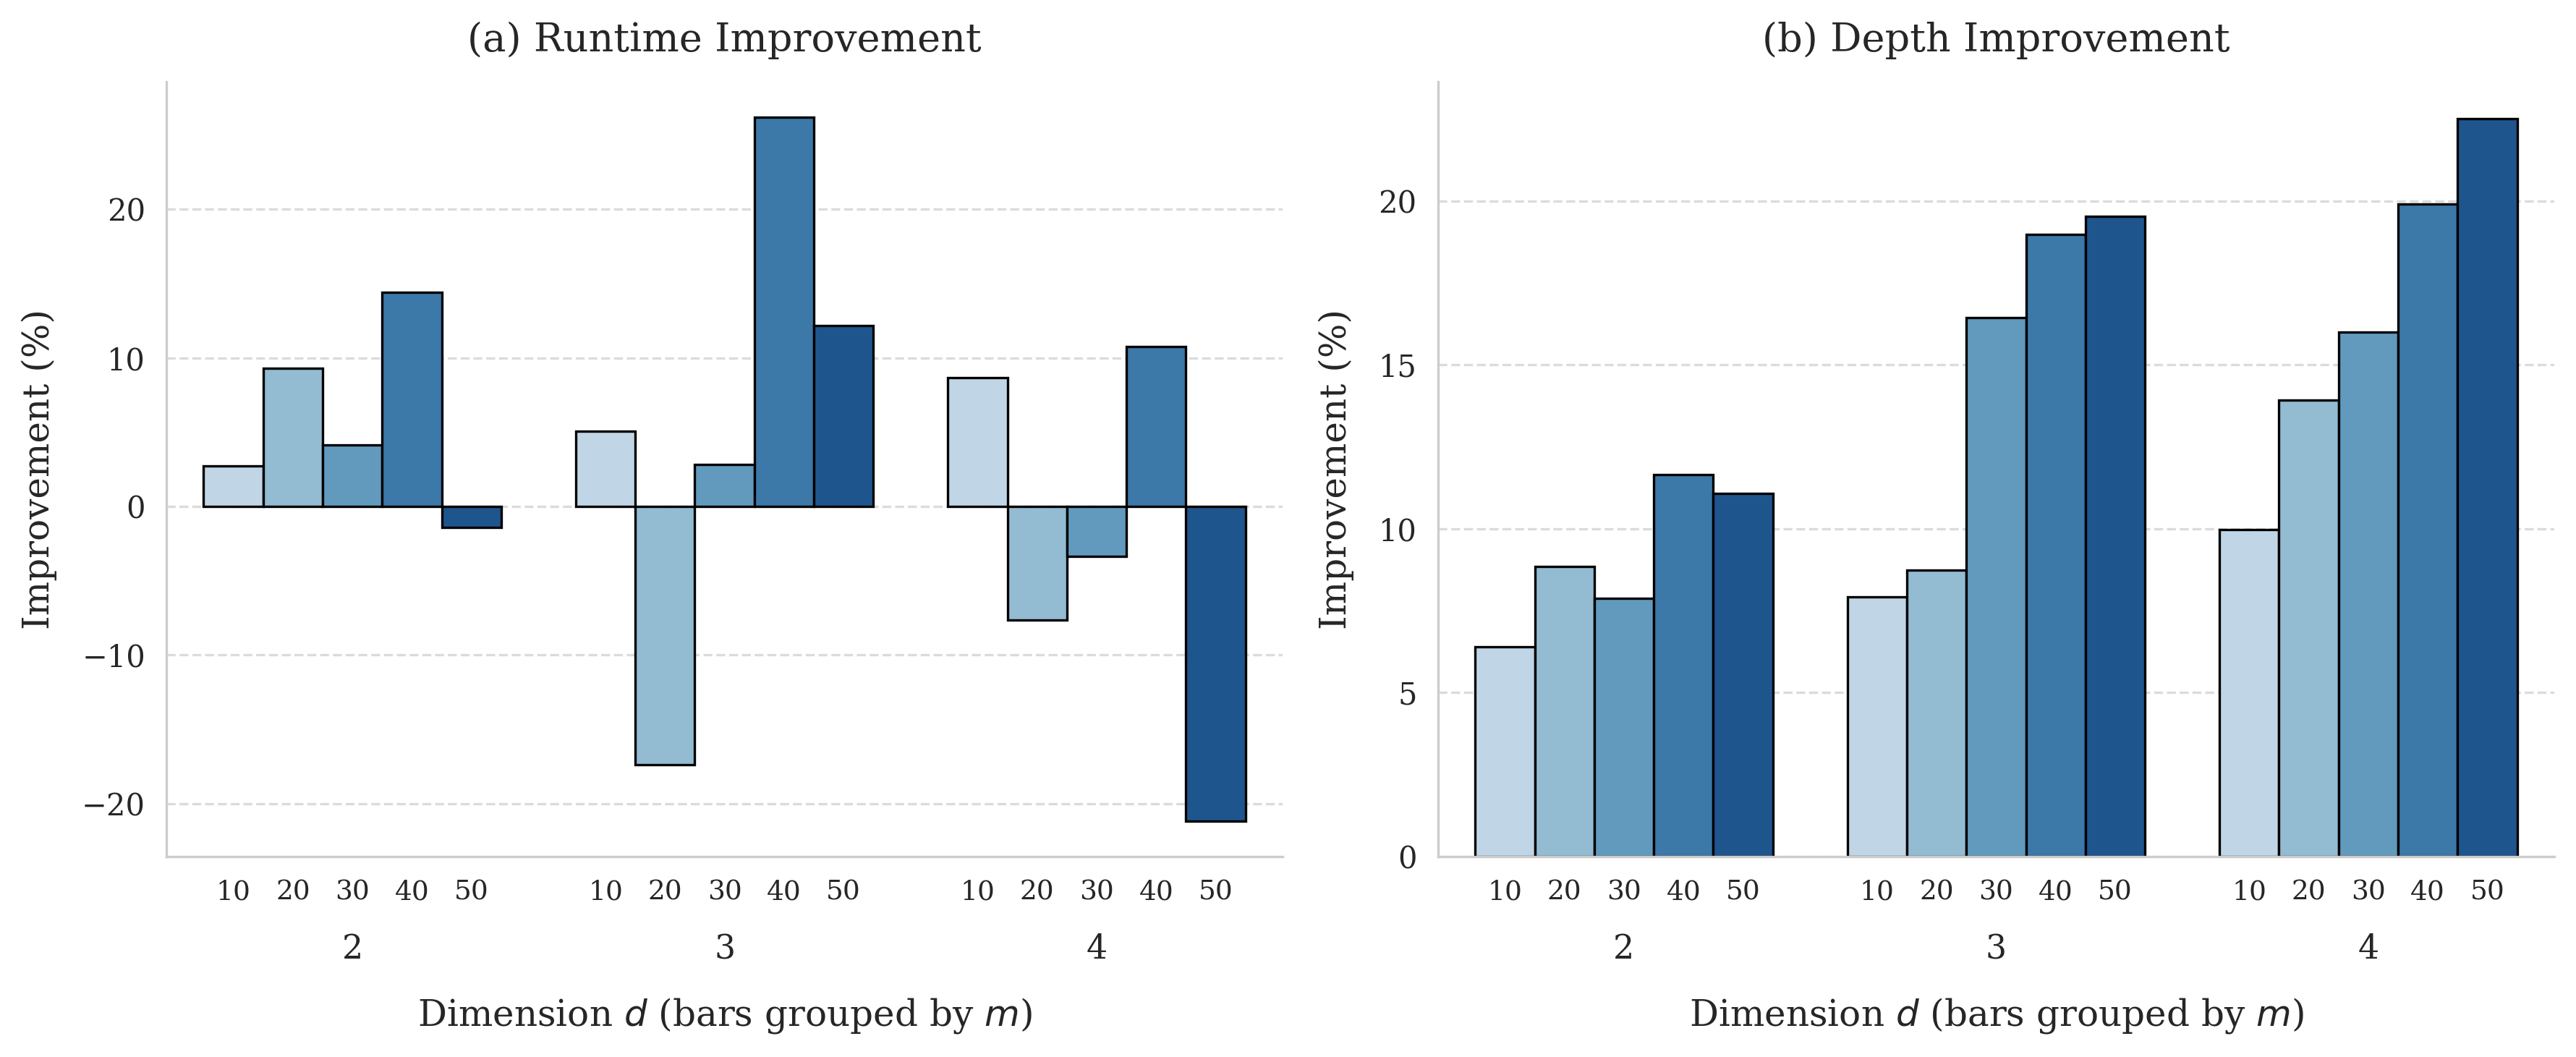

In [ ]:
# Create a grouped bar chart to compare the average improvement (positive if v-entropy is better) in runtime and average depth for each d and for each m
improvement_data = []
for d in loaded_random_results:
    for m in loaded_random_results[d]:
        v_time = loaded_random_results[d][m]["v-entropy"]["time"]
        r_time = loaded_random_results[d][m]["random"]["time"]
        time_improvement = (r_time - v_time) / r_time * 100  # Percentage improvement

        v_depth = loaded_random_results[d][m]["v-entropy"]["avg_depth"]
        r_depth = loaded_random_results[d][m]["random"]["avg_depth"]
        depth_improvement = (
            (r_depth - v_depth) / r_depth * 100
        )  # Percentage improvement

        improvement_data.append(
            {
                "d": d,
                "m": m,
                "time_improvement": time_improvement,
                "depth_improvement": depth_improvement,
            }
        )
# 1. Convert to DataFrame and SORT
df = pd.DataFrame(improvement_data)
# CRITICAL: Sort by 'd' then 'm' so bars are always in increasing order of m
df = df.sort_values(by=["d", "m"])

# --- ACADEMIC STYLING ---
plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.labelsize": 12,
        "font.size": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "figure.dpi": 300,
    }
)

# 2. Create the 1x2 Subplot Grid
# Slightly taller figure to accommodate the double labels at the bottom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 3. Sequential Palette
unique_m = df["m"].unique()
num_m = len(unique_m)
palette = sns.color_palette("Blues", n_colors=num_m + 1)[1:]

# 4. Plot 1: Runtime Improvement
sns.barplot(
    data=df,
    x="d",
    y="time_improvement",
    hue="m",
    ax=axes[0],
    palette=palette,
    edgecolor="black",
    linewidth=0.8,
)
axes[0].set_title("(a) Runtime Improvement", fontsize=13, pad=10)
axes[0].set_ylabel("Improvement (%)", labelpad=8)

# 5. Plot 2: Depth Improvement
sns.barplot(
    data=df,
    x="d",
    y="depth_improvement",
    hue="m",
    ax=axes[1],
    palette=palette,
    edgecolor="black",
    linewidth=0.8,
)
axes[1].set_title("(b) Depth Improvement", fontsize=13, pad=10)
axes[1].set_ylabel("Improvement (%)", labelpad=8)

# 6. Apply Two-Tier Custom X-Axis to Both Plots
for ax in axes:
    # Remove the hue legend completely
    ax.get_legend().remove()

    # Push the main x-axis labels (Dimension d) down to make room for m values
    ax.tick_params(axis="x", which="major", pad=22)
    ax.set_xlabel("Dimension $d$ (bars grouped by $m$)", labelpad=10)

    # Grid and Spine clean-up
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)

    # Iterate through the bar containers (each container is one value of 'm')
    for i, container in enumerate(ax.containers):
        m_val = unique_m[i]
        # Iterate through each physical bar in this group
        for bar in container:
            # Calculate the exact center of the bar
            x_pos = bar.get_x() + bar.get_width() / 2

            # Place the 'm' value directly under the bar.
            # y=-0.03 places it just below the axis line using the axis transform.
            ax.text(
                x=x_pos,
                y=-0.03,
                s=f"{m_val}",
                ha="center",
                va="top",
                fontsize=9,
                transform=ax.get_xaxis_transform(),
            )

# Final Polish
sns.despine()
plt.tight_layout()

# Save outputs
plt.savefig(
    "figures/appendix_subplots_double_axis.pdf", bbox_inches="tight", format="pdf"
)
plt.savefig("figures/appendix_subplots_double_axis.png", bbox_inches="tight", dpi=300)